# Test reinforcement learning

Adapted from last year's students Emil Johansson and Linnéa Bäckvall's RL code

In [1]:
import numpy as np
from pyworld3 import World3
from matplotlib import pyplot as plt
import pandas as pd
from tqdm import tqdm

In [2]:
max_year = 2100
world_reference = World3(year_max=max_year)
world_reference.set_world3_control()
world_reference.init_world3_constants()
world_reference.init_world3_variables()
world_reference.set_world3_table_functions()
world_reference.set_world3_delay_functions()
world_reference.run_world3(fast=False) # want to be able to set fast=True

def reward_hwi(world, k=None):
    reward = world.hwi
    if k is None:
        return reward
    else:
        return reward[k]

In [3]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

max_year = 2100
filepath = "datasets/data_reward_hwi.parquet" # hårdkodat
df = pd.read_parquet(filepath)
state_variables = df.columns[df.columns != "J"]

reward_name = "HWI"
reward_func = reward_hwi

In [4]:
class neuralNet(nn.Module):
    def __init__(self, in_dim, out_dim):
        # 2 hidden layers
        super(neuralNet, self).__init__()
        self.input_layer = nn.Linear(in_features=in_dim, out_features=32)
        self.hidden_layer1 = nn.Linear(in_features=32, out_features=64) 
        self.hidden_layer2 = nn.Linear(in_features=64, out_features=32)
        self.outLayer = nn.Linear(in_features=32, out_features=out_dim)

    def forward(self, x):
        # forward pass with relu activation function
        #ones = torch.ones((x.shape[0], 1))
        #x = torch.cat((x, ones), dim=1)
        x = self.input_layer(x)
        x = torch.relu(self.hidden_layer1(x))
        x = torch.relu(self.hidden_layer2(x))
        x = self.outLayer(x)
        return x

In [5]:
X = df.drop(columns=["J"]).to_numpy()
J = df["J"].to_numpy().reshape(-1,1)

X_train, X_test, J_train, J_test = train_test_split(X, J, test_size=0.2, random_state=42)

# normalizing
X_normalizer = StandardScaler()
X_train = X_normalizer.fit_transform(X_train)
X_test = X_normalizer.transform(X_test)
J_normalizer = StandardScaler()
J_train = J_normalizer.fit_transform(J_train)
J_test = J_normalizer.transform(J_test)

# turning into pytorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
J_train = torch.tensor(J_train, dtype=torch.float32)
J_test = torch.tensor(J_test, dtype=torch.float32)

In [6]:
model = neuralNet(X_train.shape[1], 1)
loss_func = nn.MSELoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) 

epochs = 200
losses = np.zeros((epochs,1))
test_losses = np.zeros((epochs,1))


for epoch in tqdm(range(epochs)):
    model.train()
    J_pred = model.forward(X_train)
    loss = loss_func(J_pred, J_train)

    optimizer.zero_grad() 
    loss.backward() 
    optimizer.step() 
    losses[epoch] = loss.item()

    model.eval()
    with torch.no_grad():
        J_pred_test = model.forward(X_test)
        loss_test = loss_func(J_pred_test, J_test)
        test_losses[epoch] = loss_test

100%|██████████| 200/200 [00:01<00:00, 106.78it/s]


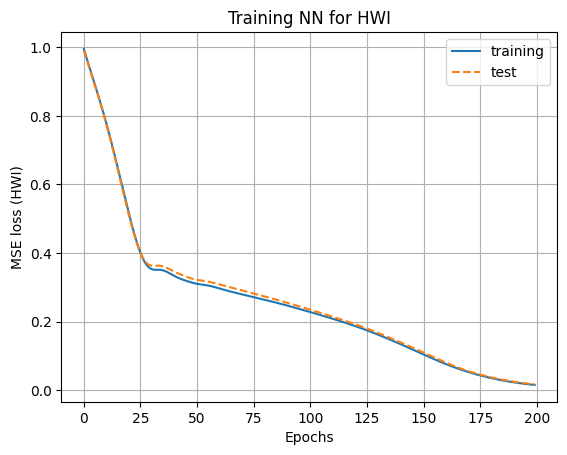

In [7]:
plt.plot(losses, label="training")
plt.plot(test_losses, label="test", linestyle='--')

plt.xlabel("Epochs")
plt.ylabel(f"MSE loss ({reward_name})")
plt.title(f"Training NN for {reward_name}")
plt.legend(), plt.grid(), 
#plt.savefig(f"plots/{reward_name}_training") # want to save in the future
plt.show()

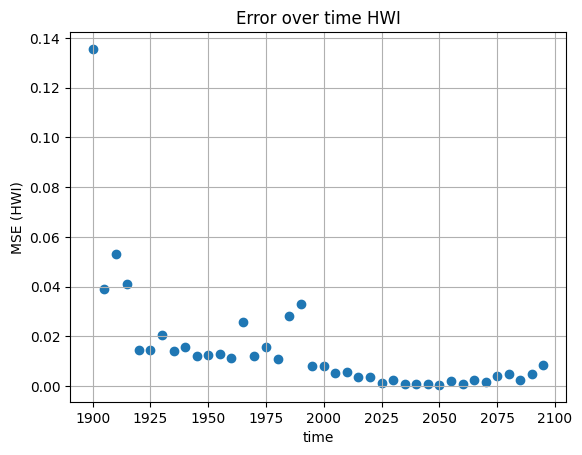

In [8]:
X_numpy = X_normalizer.inverse_transform(X_test.numpy())
J_numpy = J_test.numpy()

time_index = state_variables.get_loc('time')
errors = []
years = []

for year in range(1900, 2100, 5):
    condition = (X_numpy[:, time_index] < year+5) & (X_numpy[:, time_index] >= year)  # all rows where the condition is true
    row_indices = np.where(condition)[0]

    X_rows =  X_normalizer.transform(X_numpy[row_indices,:])

    model.eval()
    with torch.no_grad():
        J_pred = model.forward(torch.tensor(X_rows, dtype=torch.float32))
    error = np.sum((J_pred.numpy() - J_numpy[row_indices])**2) / row_indices.size
    errors.append(error)
    years.append(year)

plt.scatter(years, errors)
plt.xlabel("time")
plt.ylabel(f"MSE ({reward_name})")
plt.title(f"Error over time {reward_name}")
plt.grid()
#plt.savefig(f"plots/{reward_name}_time_error") # want to save in the future
plt.show()

In [9]:
def nn_func(model, world, k):
    """ 
    model: neural network model
    world: World3 object
    k: current iteration

    Returns
        J_hat
    """
    model.eval()
    state = np.array([getattr(world, var)[k] for var in state_variables])
    state = X_normalizer.transform(state.reshape(1, -1))
    state = torch.tensor(state, dtype=torch.float32)
    with torch.no_grad():
        J_ = J_normalizer.inverse_transform(model.forward(state))
    return J_.item()

In [10]:
def loop0(world):
    world.redo_loop = True
    while world.redo_loop:  # unsorted updates at initialization only
        world.redo_loop = False
        world.loop0_population()
        world.loop0_capital()
        world.loop0_agriculture()
        world.loop0_pollution()
        world.loop0_resource()
    

def generate_fioac_control_values(world3, k):
    current_value = world3.fioac_control(k-1)
    lower_bound = max(current_value - 0.3, 0)   # Ensure the minimum value is at least 0
    upper_bound = min(current_value + 0.3, 1)   # Ensure that the maximum value is at least 0
    return np.linspace(lower_bound, upper_bound, 15)

def generate_isopc_control_values(world3, k):
    current_value = world3.isopc_control(k-1)
    lower_bound = max(current_value - 0.4, 0.01)   # Ensure the minimum value is at least 0,01 to avoid div with zero
    upper_bound = min(current_value + 0.4, 2)
    return np.linspace(lower_bound, upper_bound, 15)


def get_control(world3, k, steps, J_hat):
    """ 
    In:
        world3: pyworld3 simulation
        k: current iteration
        steps: how many steps to look ahead
        J_hat: Approximation of J function
    Returns:
        control: fioac control value, isopc control value
    """
    # _self._loopk_world3_fast(k_ - 1, k_, k_ - 1, k_)  # sorted updates
    n = world3.n
    steps = min(steps,n-k)
    
    best_J = -np.inf
    fioac_controls = generate_fioac_control_values(world3, k)
    isopc_controls = generate_isopc_control_values(world3, k)

    for val in fioac_controls:
        for val2 in isopc_controls:
            reward = 0
            world3.fioac_control = lambda _: val
            world3.isopc_control = lambda _: val2
            for k_new in range(k,k+steps):
                world3.loopk_population(k_new-1, k_new, k_new-1, k_new)
                world3.loopk_capital(k_new-1, k_new, k_new-1, k_new)
                world3.loopk_agriculture(k_new-1, k_new, k_new-1, k_new)
                world3.loopk_pollution(k_new-1, k_new, k_new-1, k_new)
                world3.loopk_resource(k_new-1, k_new, k_new-1, k_new)
                if k_new != k+steps-1:
                    reward += reward_func(world3, k_new)
                else:
                    J_val = J_hat(world3, k_new)
                    reward += J_val
            if reward > best_J:
                best_J = reward
                fioac_val = val
                isopc_val = val2
    return fioac_val, isopc_val

def J_func(reward):
    """ 
    In:
        reward - numpy array: rewards for the simlation
    Out: 
        Array of J function values
    
    Computes the cumulative reward for each step onwards
    """
    iterations = reward.shape[0]
    J = np.zeros((iterations,1))
    J[iterations-1] = reward[iterations-1]
    for k in range(2,iterations+1):
        # J[n] is the reward at step n plus J[n+1]
        J[iterations-k] = reward[iterations-k] + J[iterations-k+1] 
    return J

In [11]:
world_control = World3(year_max=max_year)
world_control.set_world3_control()
world_control.init_world3_constants()
world_control.init_world3_variables()
world_control.set_world3_table_functions()
world_control.set_world3_delay_functions()

def run_control(world):
    # loop0 first
    loop0(world)
    isopc_val = 1 # change?

    for k in tqdm(range(1,world.n)):
        if k % 10 == 0 and world.time[k] >= 1950:
            J_hat = lambda world, k: nn_func(model, world, k)
            fioac_val, isopc_val = get_control(world, k, 20, J_hat)
            world.fioac_control = lambda _: fioac_val
            world.isopc_control = lambda _: isopc_val
            world.isopc_control_values[k] = isopc_val
            world._loopk_world3_fast(k-1, k, k-1, k)
        else:
            world._loopk_world3_fast(k-1, k, k-1, k)
            world.isopc_control_values[k] = isopc_val

run_control(world_control)

 25%|██▍       | 99/400 [00:12<00:39,  7.66it/s] 


UnboundLocalError: local variable 'fioac_val' referenced before assignment